# Bayesian Allocation with Thompson Sampling and Monte Carlo Rollout

**Application problem.** Allocate 100 computation units among 10 research
directions whose success probabilities are unknown. The objective is to
maximize the total number of successes.

This notebook compares three policies:

1. equal allocation;
2. ordinary Thompson sampling;
3. a Monte Carlo rollout policy using Thompson sampling as its continuation
   policy.

The implementation is adapted from the accompanying Python script into a
notebook format. It combines standard textbook treatments of Bayesian
bandits and rollout; it is not a reproduction of an authors' code repository.


## 1. Model

Direction $a\in\{1,\ldots,K\}$ is a Bernoulli arm with a hidden success
probability

$$
\mu_a \sim \operatorname{Beta}(\alpha_0,\beta_0).
$$

After choosing arm $A_t=a$, the observed reward satisfies

$$
R_t\mid A_t=a,\mu_a\sim\operatorname{Bernoulli}(\mu_a).
$$

Each hidden $\mu_a$ is sampled once at the start of an episode and remains
fixed throughout its 100 rounds. After $s_a$ observed successes and $f_a$
failures, conjugacy gives

$$
\mu_a\mid H_t\sim
\operatorname{Beta}(\alpha_0+s_a,\beta_0+f_a).
$$

We use the uninformative prior $\operatorname{Beta}(1,1)$, whose initial
mean is $1/2$.


### Hidden means, posterior beliefs, and posterior samples

These are three different objects:

| Object | Meaning | Visible to a policy? |
|---|---|---|
| `true_means[a]` | The fixed but hidden $\mu_a$ used by the environment | No |
| `posterior.means()[a]` | The current Bayesian estimate $E[\mu_a\mid H_t]$ | Yes |
| `posterior.sample(...)` | Temporary random draws from the current posterior | Yes |

The environment uses the hidden means to generate rewards. A policy receives
only its posterior and observed history, so it cannot cheat by inspecting the
true means. Hidden means are displayed only after an episode for evaluation.


In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np


POLICIES = ("equal", "thompson", "rollout")


## 2. Bayesian posterior state

`BetaPosterior` stores the two parameter arrays $\alpha$ and $\beta$.
Only the selected arm is updated after a reward is observed.


In [2]:
class BetaPosterior:
    """Current beliefs about independent Bernoulli-arm probabilities."""

    def __init__(self, number_of_arms, prior_alpha=1.0, prior_beta=1.0):
        if number_of_arms < 1:
            raise ValueError("number_of_arms must be positive")
        if prior_alpha <= 0 or prior_beta <= 0:
            raise ValueError("Beta prior parameters must be positive")

        self.alpha = np.full(number_of_arms, prior_alpha, dtype=float)
        self.beta = np.full(number_of_arms, prior_beta, dtype=float)

    @property
    def number_of_arms(self):
        return len(self.alpha)

    def means(self):
        return self.alpha / (self.alpha + self.beta)

    def sample(self, rng, size=None):
        if size is None:
            return rng.beta(self.alpha, self.beta)

        return rng.beta(
            self.alpha,
            self.beta,
            size=(size, self.number_of_arms),
        )

    def update(self, arm, reward):
        self.alpha[arm] += reward
        self.beta[arm] += 1 - reward


## 3. Hidden Bernoulli environment

`BanditEnvironment` is the only object that reveals real rewards. The leading
underscores in `_true_means` and `_reward_table` mark them as internal state;
action-selection functions never receive this object.

A common reward table is generated for all three policies in each episode.
This makes their comparison less noisy without giving any policy additional
information.


In [3]:
class BanditEnvironment:
    """Hidden world that reveals a reward only after an arm is selected."""

    def __init__(self, true_means, reward_table):
        self._true_means = np.asarray(true_means, dtype=float).copy()
        self._reward_table = np.asarray(reward_table, dtype=int).copy()
        self.pull_counts = np.zeros(len(true_means), dtype=int)

    def pull(self, arm):
        pull_number = self.pull_counts[arm]
        reward = self._reward_table[arm, pull_number]
        self.pull_counts[arm] += 1
        return int(reward)

    def pseudo_regret(self, arm):
        best_mean = np.max(self._true_means)
        return float(best_mean - self._true_means[arm])

    def allocations_by_rank(self):
        best_to_worst = np.argsort(-self._true_means)
        return self.pull_counts[best_to_worst].copy()


def make_reward_table(true_means, horizon, rng):
    """Generate potential Bernoulli rewards for a paired comparison."""
    return rng.binomial(
        1,
        true_means[:, None],
        size=(len(true_means), horizon),
    )


## 4. Equal allocation and Thompson sampling

Equal allocation cycles through the arms and ignores observed outcomes.

Thompson sampling instead draws one possible mean from each current posterior,

$$
\widetilde\mu_a\sim\operatorname{Beta}(\alpha_a,\beta_a),
$$

and chooses $\arg\max_a\widetilde\mu_a$. This automatically trades off
exploration of uncertain arms and exploitation of arms that currently appear
promising.


In [4]:
def random_argmax(values, rng):
    """Return a maximizing index, breaking numerical ties randomly."""
    candidates = np.flatnonzero(np.isclose(values, np.max(values)))
    return int(rng.choice(candidates))


def thompson_action(posterior, rng):
    """Draw one possible mean per arm and choose the largest."""
    posterior_draws = posterior.sample(rng)
    return random_argmax(posterior_draws, rng)


## 5. Monte Carlo rollout with a Thompson-sampling continuation

Let $\Pi$ denote the current posterior and let $n$ rounds remain. For every
possible action (a), rollout estimates

$$
Q_n^{\mathrm{TS}}(\Pi,a)
=\mathbb E\!\left[
\sum_{j=1}^{n}R_j
\;\middle|\;
A_1=a,\text{ then follow Thompson sampling}
\right].
$$

One simulated future works as follows:

1. draw one possible vector of true means from the current posterior;
2. keep that vector fixed throughout the simulated future;
3. force candidate action (a) now;
4. simulate the remaining actions using Thompson sampling;
5. record the total simulated reward.

Repeating this $M$ times gives $\widehat Q_n^{\mathrm{TS}}(\Pi,a)$. The
real action maximizes this estimate. Because $M$ is finite, estimation noise
can make rollout select the wrong action; it is not guaranteed to beat ordinary
Thompson sampling in every finite experiment.


In [5]:
def rollout_value(
    posterior,
    candidate_arm,
    remaining,
    simulated_means,
    reward_uniforms,
    rng,
):
    """Estimate total reward after forcing one candidate action now."""
    number_of_rollouts = len(simulated_means)
    rows = np.arange(number_of_rollouts)

    # These are copies, so planning cannot alter the real posterior.
    sim_alpha = np.tile(posterior.alpha, (number_of_rollouts, 1))
    sim_beta = np.tile(posterior.beta, (number_of_rollouts, 1))
    actions = np.full(number_of_rollouts, candidate_arm, dtype=int)
    simulated_returns = np.zeros(number_of_rollouts)

    for step in range(remaining):
        probabilities = simulated_means[rows, actions]
        rewards = (reward_uniforms[step] < probabilities).astype(int)
        simulated_returns += rewards

        sim_alpha[rows, actions] += rewards
        sim_beta[rows, actions] += 1 - rewards

        if step + 1 < remaining:
            posterior_draws = rng.beta(sim_alpha, sim_beta)
            actions = np.argmax(posterior_draws, axis=1)

    return float(simulated_returns.mean())


def rollout_action(posterior, remaining, number_of_rollouts, rng):
    """Choose the action with the largest Monte Carlo rollout estimate."""
    if remaining == 1:
        return random_argmax(posterior.means(), rng)

    # Judge every candidate under the same hypothetical worlds.
    simulated_means = posterior.sample(rng, number_of_rollouts)
    reward_uniforms = rng.random((remaining, number_of_rollouts))

    values = [
        rollout_value(
            posterior,
            candidate_arm,
            remaining,
            simulated_means,
            reward_uniforms,
            rng,
        )
        for candidate_arm in range(posterior.number_of_arms)
    ]
    return random_argmax(values, rng)


## 6. Running and comparing policies

In each real round the policy first chooses an arm from its posterior. Only
then does the environment reveal a reward, after which the posterior is
updated. All three policies face the same hidden world and potential reward
streams in a given episode.


In [6]:
def run_episode(
    policy,
    true_means,
    reward_table,
    prior_alpha,
    prior_beta,
    number_of_rollouts,
    rng,
):
    """Run one policy in one finite-horizon environment."""
    number_of_arms, horizon = reward_table.shape
    posterior = BetaPosterior(number_of_arms, prior_alpha, prior_beta)
    environment = BanditEnvironment(true_means, reward_table)
    equal_order = rng.permutation(number_of_arms)

    rewards = np.zeros(horizon, dtype=int)
    regrets = np.zeros(horizon)

    for t in range(horizon):
        remaining = horizon - t

        if policy == "equal":
            arm = int(equal_order[t % number_of_arms])
        elif policy == "thompson":
            arm = thompson_action(posterior, rng)
        elif policy == "rollout":
            arm = rollout_action(
                posterior,
                remaining,
                number_of_rollouts,
                rng,
            )
        else:
            raise ValueError(f"unknown policy: {policy}")

        # The policy has already acted before the hidden environment is used.
        reward = environment.pull(arm)
        posterior.update(arm, reward)
        rewards[t] = reward
        regrets[t] = environment.pseudo_regret(arm)

    return {
        "cumulative_reward": np.cumsum(rewards),
        "cumulative_pseudo_regret": np.cumsum(regrets),
        "allocations_by_rank": environment.allocations_by_rank(),
    }


def compare_policies(
    number_of_arms,
    horizon,
    episodes,
    number_of_rollouts,
    prior_alpha,
    prior_beta,
    seed,
):
    """Evaluate all policies on paired hidden worlds and reward streams."""
    results = {policy: [] for policy in POLICIES}
    hidden_worlds = []
    environment_rng = np.random.default_rng(seed)
    policy_rngs = {
        policy: np.random.default_rng(seed + i + 1)
        for i, policy in enumerate(POLICIES)
    }

    for _ in range(episodes):
        # Draw each hidden mean once and fix it for the entire episode.
        true_means = environment_rng.beta(
            prior_alpha,
            prior_beta,
            size=number_of_arms,
        )
        hidden_worlds.append(true_means.copy())
        reward_table = make_reward_table(
            true_means,
            horizon,
            environment_rng,
        )

        for policy in POLICIES:
            results[policy].append(
                run_episode(
                    policy,
                    true_means,
                    reward_table,
                    prior_alpha,
                    prior_beta,
                    number_of_rollouts,
                    policy_rngs[policy],
                )
            )

    return results, hidden_worlds


In [ ]:
def print_summary(results):
    """Print mean final performance and ranked allocations."""
    episodes = len(next(iter(results.values())))
    print(f"Mean final performance over {episodes} episode(s)")
    print(f"{'policy':<12} {'reward':>10} {'pseudo-regret':>16}")
    print("-" * 40)

    for policy, runs in results.items():
        rewards = [run["cumulative_reward"][-1] for run in runs]
        regrets = [
            run["cumulative_pseudo_regret"][-1]
            for run in runs
        ]
        print(
            f"{policy:<12} "
            f"{np.mean(rewards):>10.2f} "
            f"{np.mean(regrets):>16.2f}"
        )

    print("\nMean allocations by hidden quality rank")
    for policy, runs in results.items():
        allocations = np.stack(
            [run["allocations_by_rank"] for run in runs]
        )
        print(
            f"{policy:<12} "
            f"{np.round(allocations.mean(axis=0), 1)}"
        )


def plot_results(results):
    """Plot mean reward, pseudo-regret, and ranked allocation."""
    colors = {
        "equal": "gray",
        "thompson": "royalblue",
        "rollout": "crimson",
    }
    labels = {
        "equal": "Equal allocation",
        "thompson": "Thompson sampling",
        "rollout": "TS + rollout",
    }
    figure, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    for i, (policy, runs) in enumerate(results.items()):
        reward_curves = np.stack(
            [run["cumulative_reward"] for run in runs]
        )
        regret_curves = np.stack(
            [run["cumulative_pseudo_regret"] for run in runs]
        )
        allocations = np.stack(
            [run["allocations_by_rank"] for run in runs]
        )
        rounds = np.arange(1, reward_curves.shape[1] + 1)

        axes[0].plot(
            rounds,
            reward_curves.mean(axis=0),
            color=colors[policy],
            label=labels[policy],
        )
        axes[1].plot(
            rounds,
            regret_curves.mean(axis=0),
            color=colors[policy],
        )
        axes[2].bar(
            np.arange(1, allocations.shape[1] + 1)
            + 0.25 * (i - 1),
            allocations.mean(axis=0),
            width=0.24,
            color=colors[policy],
        )

    axes[0].set(
        title="Mean cumulative reward",
        xlabel="Round",
        ylabel="Successes",
    )
    axes[1].set(
        title="Mean cumulative pseudo-regret",
        xlabel="Round",
        ylabel="Pseudo-regret",
    )
    axes[2].set(
        title="Allocation by hidden quality rank",
        xlabel="Rank (1 = best)",
        ylabel="Allocations",
    )
    axes[2].set_xticks(np.arange(1, allocations.shape[1] + 1))
    figure.legend(loc="upper center", ncol=3, frameon=False)
    figure.tight_layout(rect=(0, 0, 1, 0.9))
    return figure


## 7. Experiment

The default below is deliberately a quick demonstration. Increasing
`episodes` stabilizes the empirical comparison; increasing
`number_of_rollouts` reduces noise in the rollout value estimates, but both
changes increase runtime.


In [8]:
number_of_arms = 10
horizon = 100
episodes = 3
number_of_rollouts = 50
prior_alpha = 1.0
prior_beta = 1.0
seed = 20260815

start = time.perf_counter()
results, hidden_worlds = compare_policies(
    number_of_arms,
    horizon,
    episodes,
    number_of_rollouts,
    prior_alpha,
    prior_beta,
    seed,
)

print_summary(results)
print(f"\nRuntime: {time.perf_counter() - start:.2f} seconds")

print("\nHidden means used for evaluation only:")
for episode, means in enumerate(hidden_worlds, start=1):
    best_arm = int(np.argmax(means))
    print(
        f"Episode {episode}: best arm={best_arm}, "
        f"mu={means[best_arm]:.4f}; "
        f"means={np.round(means, 4)}"
    )


Mean final performance over 3 episode(s)
policy           reward    pseudo-regret
----------------------------------------
equal             54.33            35.40
thompson          75.67            12.72
rollout           73.33            14.35

Mean allocations by hidden quality rank (rank 1 is best)
equal        [10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]
thompson     [30.3 15.3  8.  28.7  2.3  5.7  4.7  1.7  2.   1.3]
rollout      [29.3 14.  12.7 20.7  2.3  6.7  9.   2.3  2.   1. ]

Runtime: 6.28 seconds

Hidden means used for evaluation only:
Episode 1: best arm=8, mu=0.9633; means=[0.0152 0.3082 0.1629 0.7328 0.7503 0.7186 0.676  0.6033 0.9633 0.9183]
Episode 2: best arm=9, mu=0.9093; means=[0.2352 0.8504 0.2879 0.7322 0.7537 0.449  0.3118 0.2115 0.0018 0.9093]
Episode 3: best arm=7, mu=0.8619; means=[0.8093 0.6417 0.272  0.0513 0.6861 0.8188 0.8437 0.8619 0.4883 0.6596]


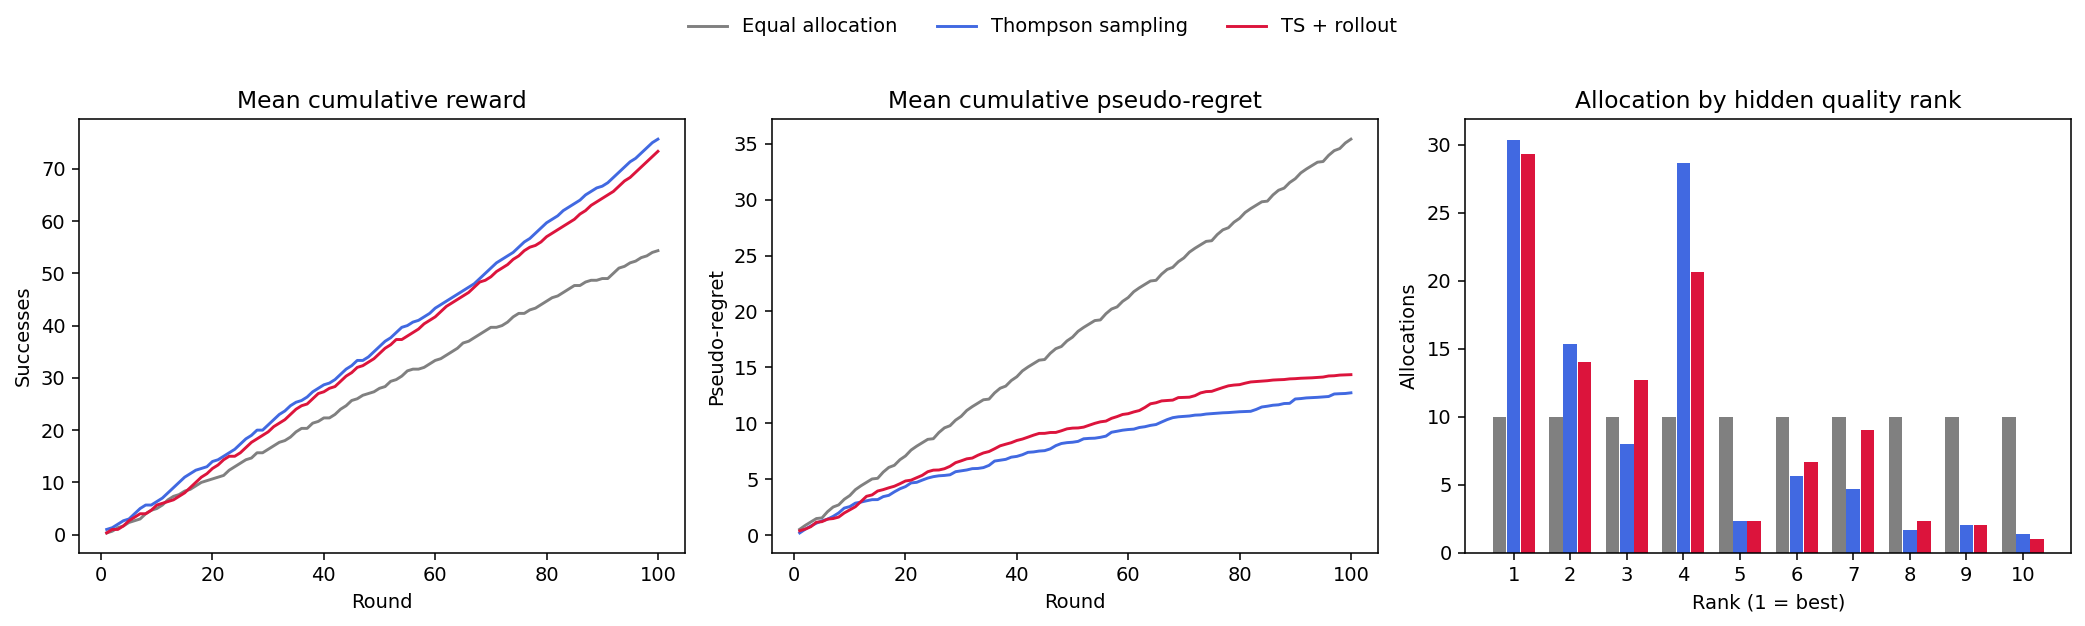

In [9]:
figure = plot_results(results)
plt.show()

# Optional: save a separate image for a report or README.
# figure.savefig("bayesian_allocation_results.png", dpi=180,
#                bbox_inches="tight")


## 8. Interpreting the output

- **Reward** is the realized number of successes, so larger is better.
- **Pseudo-regret** sums the expected loss relative to always selecting the
  hidden best arm, so smaller is better.
- Each ranked-allocation entry is the mean number of pulls assigned to the
  arm of that hidden quality rank. It can be fractional because it averages
  integer counts over several episodes.

Three episodes are sufficient to demonstrate the program, but not to establish
a statistically reliable ordering between Thompson sampling and rollout.
Exact rollout values have a policy-improvement interpretation; finite Monte
Carlo estimates can mis-rank actions. Therefore, a small run may show rollout
performing either better or worse than ordinary Thompson sampling.


## References

1. T. Lattimore and C. Szepesvári, *Bandit Algorithms*, Cambridge
   University Press, 2020, Chapters 34–36.  
   [Book page](https://www.cambridge.org/core/books/bandit-algorithms/8E39FD004E6CE036680F90DD0C6F09FC)

2. D. P. Bertsekas, *A Course in Reinforcement Learning*, 2nd edition,
   Athena Scientific, 2025, Chapters 1–2.  
   [Author's book page](https://www.mit.edu/~dimitrib/RLbook.html)
